In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/Superstore_Dataset_Task19.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2024-100000,11/23/2024,11/29/2024,Standard Class,CU-1216,Customer 17,Consumer,United States,New York City,...,22280,West,TEC-PH-10000,Technology,Phones,Apple iPhone,2393.70,5,0.00,549.80
1,2,US-2023-100001,10/12/2023,10/19/2023,Standard Class,CU-1081,Customer 217,Corporate,United States,Atlanta,...,46421,West,FUR-BO-10001,Furniture,Bookcases,O'Sullivan Bookcase,1681.29,9,0.15,220.02
2,3,US-2024-100002,09/10/2024,09/13/2024,Standard Class,CU-1235,Customer 275,Consumer,United States,Columbus,...,59615,East,FUR-TA-10002,Furniture,Tables,Bretford Conference Table,345.58,2,0.15,39.24
3,4,US-2023-100003,02/16/2023,02/22/2023,Second Class,CU-1148,Customer 41,Consumer,United States,New York City,...,23238,South,TEC-AC-10003,Technology,Accessories,Belkin Cable,2764.60,10,0.10,624.90
4,5,US-2024-100004,11/30/2024,12/06/2024,Standard Class,CU-1087,Customer 274,Home Office,United States,Seattle,...,42087,West,OFF-SU-10004,Office Supplies,Supplies,Fiskars Scissors,209.25,3,0.10,39.17


In [3]:
top_products = df.groupby("Product Name")["Sales"].sum().reset_index()
top_products = top_products.sort_values(by="Sales", ascending=False)

In [4]:
top10 = top_products.head(10)
print(top10)

           Product Name      Sales
31        Konica Copier  227102.96
13         Canon Copier  204882.49
7          Belkin Cable  142961.36
35       Logitech Mouse  139916.73
34      Lexmark Printer  119705.24
24           HP Printer   95638.96
30  Kensington Keyboard   90096.91
3          Apple iPhone   88133.07
16       Cubify Printer   87692.03
42       Samsung Galaxy   83503.75


In [5]:
top_products["Rank"] = top_products["Sales"].rank(ascending=False, method="min")
ties = top_products[top_products["Rank"] <= 10]
print(ties)

           Product Name      Sales  Rank
31        Konica Copier  227102.96   1.0
13         Canon Copier  204882.49   2.0
7          Belkin Cable  142961.36   3.0
35       Logitech Mouse  139916.73   4.0
34      Lexmark Printer  119705.24   5.0
24           HP Printer   95638.96   6.0
30  Kensington Keyboard   90096.91   7.0
3          Apple iPhone   88133.07   8.0
16       Cubify Printer   87692.03   9.0
42       Samsung Galaxy   83503.75  10.0


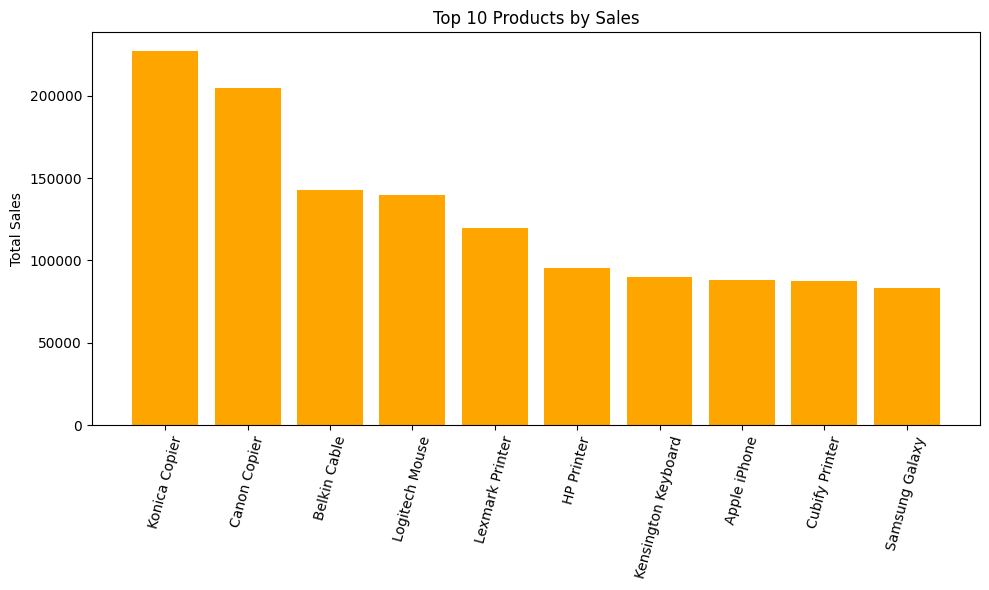

In [6]:
plt.figure(figsize=(10,6))
plt.bar(top10["Product Name"], top10["Sales"], color="orange")
plt.xticks(rotation=75)
plt.ylabel("Total Sales")
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.savefig("top10_products_chart.png")
plt.show()

In [7]:
import plotly.express as px
fig = px.bar(top10, x="Product Name", y="Sales",
             color="Sales", color_continuous_scale="Oranges",
             title="Top 10 Products by Sales", text_auto=".2s")
fig.update_layout(xaxis_tickangle=-45)
fig.show()

**## Task 19 – Top 10 Products by Sales**

This task focuses on identifying the top 10 products by total sales from the Superstore dataset and practicing ranking and sorting techniques in Python. Using Pandas, the data was grouped by product name, sales were aggregated, and the results were sorted in descending order to find the highest-selling products.

**Key Insights:**
- The top product by total sales is Konica Copier, followed closely by Canon Copier.
- Most of the top 10 products belong to the Technology category (Copiers, Printers, Mouse, Keyboard, Phones), showing this category generates the highest revenue.
- No exact ties were found in the top 10 rankings after checking with rank().
- High-value items like copiers and printers lead in total sales even though office supplies are sold in higher quantity, indicating that price per unit plays a bigger role than volume for top rankings.

Tools Used:  Python (Pandas, Matplotlib)

**Deliverables:**
- Top-10 Products Table (top10_products_table.csv)
- Sales Chart (top10_products_chart.png)

Conclusion: Technology products, especially copiers and printers, are the biggest contributors to overall sales. Focusing marketing and inventory efforts on these high-value items could help improve total revenue further.